# Hypothesis Testing with GLMs
Last semester, we saw that hypothesis testing within the normal linear model concerned either tests on individual model parameters, or omnibus tests on multiple parameters via model comparisons. The default $t$-tests on the coefficients were examples of the former, whereas the ANOVA tests based on differences in sums-of-squares were examples of the latter. Within the GLM, we can use a very similar framework, however, the details are slightly different. As such, although we can get $p$-values from a GLM using the same `summary()` and `Anova()` methods used last semester, there are some important practical details about these calculations.

## Tests on Individual Coefficients
When working with the standard linear model, we typically produce tests on the individual parameter estimates. For instance, a $t$-test comparing the estimate of $\beta_{1}$ to a proposed null value of $\beta_{1} = 0$ takes the form

$$
t = \frac{\hat{\beta}_{1} - 0}{\sqrt{\text{Var}(\hat{\beta}_{1})}}.
$$

These are the tests reported by default within the table produced by `summary()`. The $p$-values from these tests are then calculated using the following logic:
1. If the population distribution of the data is normal then:
    1. The sampling distribution of the regression coefficients is also normal.
    2. The sampling distribution of the variance is a scaled $\chi^{2}$ distribution.
2. Dividing a normal random variate by a scaled $\chi^{2}$ creates a new random variable that has a null $t$-distribution.
3. Using this null distribution, we can calculate a $p$-value.

The key point is that our ability to calculate a $p$-value depends upon knowing the null distribution of the test statistic, which depends upon knowing the sampling distributions of the numerator and denominator, which in turn depend upon the distribution of the data. As such, all the hypothesis testing logic we covered last semester depends upon the data coming from a normal distribution. This obviously causes an issue when we move away from the normal distribution.

### Wald Tests
The main problem with using a $t$-statistic with non-normal data is *not* that the construction of the statistic is flawed. Rather, the issue is knowing the null distribution and thus knowing how to calculate a $p$-value. As such, the idea of comparing the calculated value to a hypothesised value and then dividing by the uncertainty is sound. The issue is trying to calculate the probability of this value if the hypothesised value were true. As such, what we need is a framework that can provide us with a test statistic and a known null distribution, irrespective of how the data are distributed. 

To see how this can be achieved, we first need to recognise that the $t$-statistic is actually a special case of a much more general hypothesis-testing framework known as a *Wald test*. This framework was proposed by [Wald (1943)](https://www.pp.rhul.ac.uk/~cowan/stat/wald1943.pdf?utm_source=chatgpt.com) and is deceptively simple. For some parameter estimate $\hat{\theta}$ derived from maximum likelihood, and a hypothesised null value $\theta_{0}$, a test statistic can be constructed using

$$
W = \frac{(\hat{\theta} - \theta_{0})^{2}}{\text{Var}(\hat{\theta})},
$$

which looks very similar to a $t$-statistic. In fact, taking the square-root of $W$ gives

$$
\sqrt{W} = \frac{\hat{\theta} - \theta_{0}}{\sqrt{\text{Var}(\hat{\theta})}},
$$

which is even more $t$-like. However, the form of the test statistic is not our main concern. The fact that this is similar to the logic of the $t$-statistic is helpful as we can understand the value of $W$ in familiar terms. Furthermore, it is advantageous that the $t$-statistic is simply a special form of $W$ because it means we are working within the same framework for hypothessis testing. However, the most pressing practical issue when using NHST is knowing how this value is distributed under the null and thus how to calculate a $p$-value.

#### Asymptotic Validity
Under the normal linear model, the distribution of $t$ comes directly from the assumption of normality. Because the Wald test makes no assumptions about the distribution of the data, it must instead rely on properties of the *estimator*. More specifically, the Wald test depends upon: 
1. The *asymptotic* [^foot-1] distribution of maximum likelihood estimates
2. The assumption that the variance of these estimates is known

In terms of the first point, it can be shown that as the sample size gets bigger, the sampling distribution of the maximum likelihood estimate becomes more and more normal. This works under fairly general conditions for anything that is estimated by maximum likelihood, whether the data itself are normal or not. The usual way of expressing this is to say that the sampling distribution is *asymptotically* normal, which means as $n \rightarrow \infty$. This is illustrated via simulation in the plots below. When $n$ is small, the sampling distribution is noticeably skewed. However, as $n$ gets larger, the distribution gets closer and closer to a normal distribution.

[^foot-1]: Pronounced "ah-simp-TOT-ik", with the stress on the "TOT".

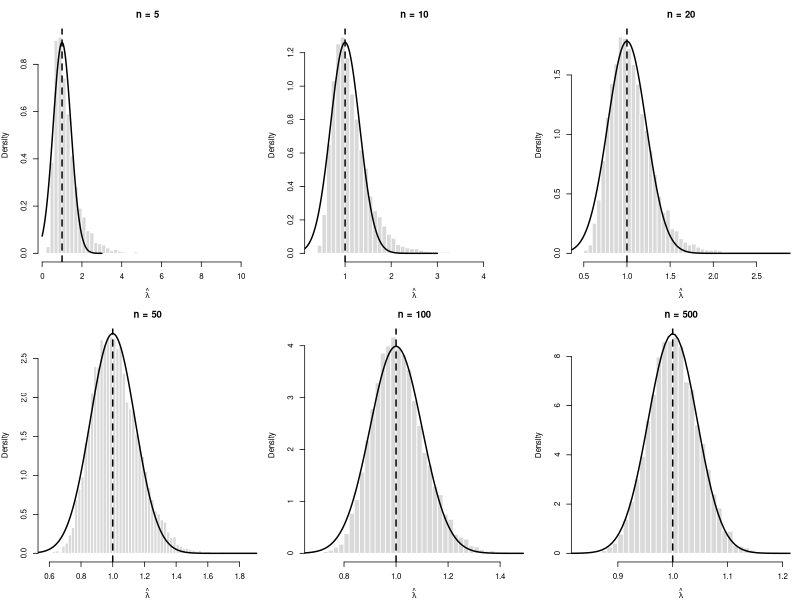

In [ ]:
set.seed(123)

# True parameter
lambda <- 1

# Sample sizes
sample_sizes <- c(5, 10, 20, 50, 100, 500)

# Number of simulated datasets
n_sim <- 10000

# Set up plotting grid
par(mfrow = c(2, 3),
    mar = c(4, 4, 3, 1))

for (n in sample_sizes) {

  # Simulate MLEs
  lambda_hat <- replicate(
    n_sim,
    {
      y <- rexp(n, rate = lambda)
      1 / mean(y)
    }
  )

  # Histogram
  hist(
    lambda_hat,
    probability = TRUE,
    breaks = 50,
    xlim = c(0, 3),
    main = paste("n =", n),
    xlab = expression(hat(lambda)),
    ylab = "Density",
    col = "grey85",
    border = "white"
  )

  # Asymptotic normal distribution
  x <- seq(0, 3, length.out = 500)

  lines(
    x,
    dnorm(
      x,
      mean = lambda,
      sd = lambda / sqrt(n)
    ),
    lwd = 2
  )

  # True parameter value
  abline(
    v = lambda,
    lty = 2,
    lwd = 2
  )
}

In terms of the second point, the variance of a maximum likelihood estimator can also be calculated but, again, this relies on asymptotic theory. This uses something called *Fisher Information* to derive the variance of the estimate, but this only works as $n \rightarrow \infty$. As such, when the sample is large, the distribution of the numerator is known and the denominator can be calculated. Furthermore, even thought the denominator remains an *estimate* (because it is still calculated from a sample), if we assume that the sample size is large enough then we can effectively treat this value as *known* [^foot-2]. When we do so, the Wald statistic $W$ is simply dividing a random variable with a known distribution by a *constant*, which has the effect of simply *scaling* that distribution. In the case of $\sqrt{W}$ this gives

$$
    \sqrt{W} \sim \mathcal{N}(0,1),
$$

and in the case of $W$ this gives

$$
    W \sim \chi^{2}(1).
$$

As such, the asymptotic $p$-value for a Wald test can be derived from either a $\chi^{2}$ distribution with 1 degree of freedom, or from a standard normal distribution. Because of this, these test statistics are usually referred to as $z$ or $\chi^{2}$, in reference to their asymptotic distributions.

[^foot-2]: More precisely, the variation in the estimation of the variance has become so negligibly small that it makes basically no difference now.

```{tip} Key Point
As long as the sample is large enough, the numerator of the Wald statistic $W$ can be taken as normally distributed and the denominator can be taken as a known constant, thanks to the asymptotic properties of maximum likelihood. Under these conditions, the Wald statistic is simply scaling a random variable with a known distribution, leading to either a standard normal or a $\chi^{2}$ as the null distribution of the test.
```

Taking all this together, the biggest practical lesson is that the Wald framework can be easily applied to GLMs, but that the $p$-values are only truly valid under *large samples*. More generally, this tells us that the tests on the coefficients from a GLM are much less certain than under the standard linear model. As the sample size increases, we can become more confident in their value. However, with small samples we need to be much more cautious.

## Model Comparisons
Last semester, we saw how tests on multiple parameters can be conceptualised in terms of *model comparisons*. More specifically, we can compare a model containing the parameters of interest (the *full* model) to a model that does *not* contain the parameters of interest (the *null* model). The degree to which the error reduces between these models is equivalent to the sum-of-squares from the traditional ANOVA table. As such, the ANOVA is most simply conceptualised as a *model comparison procedure*.

### Generalising Sums-of-Squares to Deviance
A very similar perspective can be taken with GLMs. However, the process needs to be more general and applicable to data from non-normal distributions. To achieve this, the concept of the *residual sums-of-squares* (RSS) from the normal linear model can be generalised to a related concept called *deviance*.

Deviance is based on comparing a model to a *saturated* version of the model that has enough parameters to fit the observed data as closely as possible. In other words, deviance tells us how our model differ from the best possible job that the model could do. This has a direct connection to error in the normal linear model, where the residuals tell us how far the fitted values are from a perfect fit to the observed data.

As an example, we might have a Poisson model that assumes

$$
y_i \sim \text{Pois}(\lambda),
$$

such that there is a global $\lambda$ parameter and thus a single distribution from which all of the data arise. A saturated version of this would be

$$
y_i \sim \text{Pois}(\lambda_i),
$$

such that each datapoint has its own separate parameter. As there is no other information to constrain these parameters, $\hat{\lambda}_i = y_i$, making each observed value as likely as possible under a Poisson model.

The deviance tells us how far our fitted model is from this *perfect* fit and is defined as

$$
    D_{{M}_{1}} = 2 \left(\log\left[p\left(y|\mathcal{M}_{s}\right)\right] - \log\left[p(y|\mathcal{M}_{1})\right]\right),
$$

where $\mathcal{M}_1$ is our model of interest and $\mathcal{M}_s$ is the saturated model. The terms $\log\left[p(y|\mathcal{M}_{1})\right]$ and $\log\left[p(y|\mathcal{M}_{s})\right]$ are known as the *log-likelihood* and can be written as $\ell$, allowing this expression to be simplified and the structure made clearer

$$
    D_{{M}_{1}} = 2\left(\ell(\mathcal{M}_s) - \ell(\mathcal{M}_1)\right).
$$

In simple terms, this compares how well our model explains the observed data with how well the data could possibly be fitted under the assumed probability distribution.

Importantly, 0 deviance is never the aim. We want the fit to be close, so a smaller deviance, but never 0 as this would imply *over-fitting* and thus that we were capturing both signal and noise, rather than separating them. Remember as well, the law of parsimony. We want our model to be a useful *simplification* of reality and thus perfection is never the aim.

### Comparing Deviance Between Models
If deviance is therefore the analogue to the sums-of-squares in a linear model, we can approach model comparison in much the same way by calculating the *reduction in deviance* between two competing models. So, under the normal linear model we might construct a test using

$$
    RSS_{reduced} - RSS_{full}
$$

for a GLM, we can instead use

$$
    D_{reduced} - D_{full}.
$$

This then raises the possibility of construction an ANOVA-like table of omnibus tests from a GLM which, more correctly, can be termed an *Analysis of Deviance*. Using Wilks' Theorem, this difference of deviance is known to be aymptotically distributed as $\chi^{2}(k)$, where $k$ is the difference in the number of parameters between the two models. So, much like the Wald tests, we have an asymptotic means of calculating a $p$-value for an omnibus ANOVA-like test from a GLM. 

Although this has all the same limitations as the Wald test, we are now in the very useful position of being able to use an ANOVA-style model with non-normal data. More broadly, this allows for the analysis of factorial experiments where the outcome variable is binary, a count, heavily skewed or some other form that makes the normal distribution inappropriate. 

:::{tip .simple icon=false} What You Now Know
In this section, we have discussed how hypothesis tests can be conducted within the GLM framework. After reading this section, you should have a good sense of:
- A Wald test as very similar to a $t$-test, but with the important distinction that the test is based on the asymptotic normality of the maximum likelihood estimates *and* the variance of the maximum likelihood estimate being known.
- The idea that because of this construction, the Wald test is *asymptotically* distributed as a $\chi^{2}$, with the square-root producing a statistic $z$ that has an asymptotic standard normal distribution.
- The limitation that $p$-values derived from these tests are only *asymptotically valid* and thus are less trustworthy under small samples.
- Deviance as a generalisation of variance from the standard linear model.
- Comparisons of deviance across nested models provides a similar idea to comparisons of sums-of-squares in an ANOVA, allowing the same model comparison perspective to be used for generating omnibus tests. 
:::